# 09 · NLP sobre las reseñas (portugués)  *(sección 9 del script)*

**Qué hacemos:** procesamiento de lenguaje natural básico sobre los **comentarios en portugués** de las reseñas:

1. Función de **limpieza de texto** (minúsculas, sin tildes, sin puntuación/números).
2. **Stopwords** en portugués (NLTK, con lista de respaldo embebida por si no hay conexión).
3. Tres **bolsas de palabras**: todas las reseñas con comentario, solo las **negativas** (1-2 ★) y solo las **positivas** (4-5 ★).
4. **Nubes de palabras** (general / negativas / positivas) y un **ranking de frecuencia** de las 15 palabras más usadas en las reseñas negativas.

**Para qué:** el puntaje numérico dice *qué* opinan los clientes; el texto dice **por qué**. Este notebook aporta la evidencia cualitativa de la hipótesis 2: *el contenido de las reseñas negativas está dominado por menciones a demoras/entrega*.

## Celda estándar: carga del artefacto + guardado de figuras

In [1]:
# Celda estándar (detallada en 01_configuracion_inicial.ipynb)
%matplotlib inline

import re
import unicodedata
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

BASE = Path.cwd()
if not (BASE / "data").exists() and (BASE.parent / "data").exists():
    BASE = BASE.parent

CSV_UNIFICADO = BASE / "data" / "olist_dataset_unificado.csv"
PIPELINE_DIR = BASE / "data" / "pipeline"
FIGS_DIR = BASE / "figuras_eda"

OLIST_BLUE = "#0A4EE4"
OLIST_BLUE_DARK = "#0D366B"
OLIST_GRAY = "#52514E"
PALETA_CATEGORICA = ["#0A4EE4", "#eb6834", "#1baf7a", "#eda100",
                     "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SUDESTE = {"SP", "RJ", "MG", "ES"}

sns.set_theme(style="whitegrid", rc={
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": OLIST_GRAY,
    "text.color": "#0b0b0b",
    "xtick.color": OLIST_GRAY,
    "ytick.color": OLIST_GRAY,
    "font.family": "sans-serif",
})
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", 50)

# --- Carga del artefacto del notebook 04 ---
COLUMNAS_FECHA = [
    "shipping_limit_date", "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

RUTA_FEATURES = PIPELINE_DIR / "02_df_features.csv"
if not RUTA_FEATURES.exists():
    raise FileNotFoundError(
        f"No existe {RUTA_FEATURES}. Ejecutá primero los notebooks 02, 03 y 04."
    )

df = pd.read_csv(RUTA_FEATURES)
for col in COLUMNAS_FECHA:
    df[col] = pd.to_datetime(df[col], errors="coerce")
df["mes_compra"] = df["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()

# --- Guardado de figuras de este notebook ---
def configurar_guardado(prefijo):
    FIGS_DIR.mkdir(exist_ok=True)
    contador = {"n": 0}

    def guardar():
        contador["n"] += 1
        ruta = FIGS_DIR / f"{prefijo}_{contador['n']:02d}.png"
        plt.savefig(ruta, dpi=110, bbox_inches="tight")
        return ruta

    return guardar


guardar_fig = configurar_guardado("nb09")
print(f"filas={df.shape[0]:,} columnas={df.shape[1]} | figuras -> {FIGS_DIR}")

filas=112,650 columnas=43 | figuras -> D:\Ciencia de Datos\Proyecto Integrador\trabajo_ integrador_versionNati\trabajo_ integrador_versionNati\figuras_eda


## Paso 1 — Limpieza de texto

**Qué hacemos:** función `limpiar_texto`, paso a paso:

1. **Minusculizar** (`.lower()`) → "Excelente" y "excelente" pasan a ser la misma palabra.
2. **Quitar tildes** con `unicodedata.normalize("NFKD")` + `encode("ascii", "ignore")` → "atraso" y "atrasó" se unifican (clave en portugués, idioma muy acentuado).
3. **Eliminar todo lo que no sea letra o espacio** con `re.sub(r"[^a-z\s]", " ", texto)` → puntuación y números desaparecen (y quedan como espacio, para que no se peguen palabras).
4. **Colapsar espacios múltiples** (`re.sub(r"\s+", " ", ...)`) y `.strip()`.

**Para qué:** es el paso previo para que las nubes de palabras y los rankings de frecuencia **tengan sentido**: sin esta limpieza, "PRODUTO!!!" y "produto" serían palabras distintas, y los signos aparecerían como "palabras" más frecuentes que cualquier contenido real.

In [2]:
def limpiar_texto(texto):
    if pd.isna(texto) or texto == "":
        return ""
    texto = str(texto).lower()
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")
    texto = re.sub(r"[^a-z\s]", " ", texto)
    return re.sub(r"\s+", " ", texto).strip()


# Demostración con 3 reseñas reales del dataset
muestra_txt = df.loc[df["tiene_comentario"] == 1, "review_comment_message"].head(3)

demo = pd.DataFrame({
    "original": muestra_txt.values,
    "limpia": [limpiar_texto(t) for t in muestra_txt],
})
demo

,original,limpia
0,"Perfeito, produto entregue antes do combinado.",perfeito produto entregue antes do combinado
1,Chegou antes do prazo previsto e o produto sur...,chegou antes do prazo previsto e o produto sur...
2,Gostei pois veio no prazo determinado .,gostei pois veio no prazo determinado


**Insight:** se ve la transformación en acción: mayúsculas, tildes, signos de exclamación y números quedan normalizados — las variantes de una misma palabra convergen en un único token.

## Paso 2 — Stopwords en portugués

**Qué hacemos:** cargamos la lista de **stopwords** (palabras funcionales vacías: "de", "que", "o", "e"…) de NLTK para portugués. Si NLTK no puede descargarlas (sin internet), usamos una **lista de respaldo propia** embebida en el código (`STOPWORDS_PT_RESPALDO`), para que el notebook funcione 100% offline.

**Para qué:** las stopwords son, por definición, las palabras **más frecuentes de cualquier texto**; si no se filtran, ocuparían el 90% de la nube de palabras y taparían el contenido real ("prazo", "atraso", "entrega"…).

In [3]:
STOPWORDS_PT_RESPALDO = (
    "de a o que e do da em um para com nao uma os no se na por mais as dos como mas "
    "ao ele das a sua ou quando muito nos ja eu tambem so pelo pelas pela ate isso "
    "ela entre depois sem mesmo aos seus quem nas me esse eles voce essa num nem "
    "suas meu as minha numa pelos elas qual sera nos tenho lhe deles essas esses "
    "pelas este fosse dela tu te voces vos lhes meus minhas teu tua teus tuas "
    "nosso nossa nossos nossas dele"
).split()

try:
    import nltk
    nltk.download("stopwords", quiet=True)
    from nltk.corpus import stopwords
    STOPWORDS_PT = set(stopwords.words("portuguese"))
    origen = "NLTK (portugués)"
except Exception:
    STOPWORDS_PT = set(STOPWORDS_PT_RESPALDO)
    origen = "lista de respaldo embebida (offline)"

print(f"Stopwords: {len(STOPWORDS_PT)} | origen: {origen}")
print("Ejemplos:", sorted(STOPWORDS_PT)[:15])

Stopwords: 207 | origen: NLTK (portugués)
Ejemplos: ['a', 'ao', 'aos', 'aquela', 'aquelas', 'aquele', 'aqueles', 'aquilo', 'as', 'até', 'com', 'como', 'da', 'das', 'de']


## Paso 3 — Tres bolsas de palabras

**Qué hacemos:**

- Armamos `review_limpia` aplicando `limpiar_texto` a todos los comentarios.
- Con `armar_texto` construimos tres textos unidos, **filtrando stopwords y palabras de 1-2 letras** (`largo_min=2`, que en portugués son artículos/preposiciones residuales): **general** (todo lo que tiene comentario), **negativo** (1-2 ★) y **positivo** (4-5 ★).

**Para qué:** separar por sentimiento es lo que permite **contrastar el vocabulario** de insatisfechos vs. satisfechos — sin esa separación, la nube general mezcla las dos voces en una sola.

In [4]:
df["review_limpia"] = df["review_comment_message"].apply(limpiar_texto)


def armar_texto(serie, sw, largo_min=2):
    palabras = " ".join(serie).split()
    return " ".join(p for p in palabras if p not in sw and len(p) > largo_min)


con_comentario = df["tiene_comentario"] == 1
texto_general = armar_texto(df.loc[con_comentario, "review_limpia"], STOPWORDS_PT)
texto_neg = armar_texto(df.loc[con_comentario & (df["review_score"] <= 2), "review_limpia"], STOPWORDS_PT)
texto_pos = armar_texto(df.loc[con_comentario & (df["review_score"] >= 4), "review_limpia"], STOPWORDS_PT)

print(f"Reseñas con comentario escrito: {con_comentario.sum():,}")
print(f"Tokens -> general={len(texto_general.split()):,} | "
      f"negativos={len(texto_neg.split()):,} | positivos={len(texto_pos.split()):,}")

Reseñas con comentario escrito: 47,471
Tokens -> general=349,005 | negativos=142,304 | positivos=169,419


## Nube 1 — General

**Qué hacemos:** nube de palabras con **todas** las reseñas que tienen comentario (`WordCloud`, 100 palabras máx., colormap azul, `collocations=False` para no agrupar bigramas).

**Para qué:** una **primera foto visual** de qué se comenta más, en general, sobre las compras en Olist — antes de separar por sentimiento.

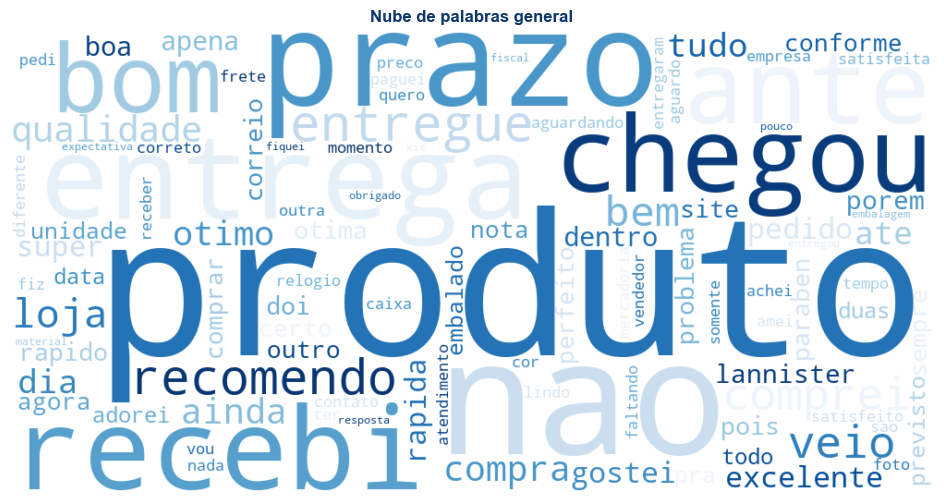

In [5]:
from wordcloud import WordCloud

nube_general = WordCloud(width=1000, height=500, background_color="white",
                          colormap="Blues", max_words=100, collocations=False).generate(texto_general)
plt.figure(figsize=(12, 6))
plt.imshow(nube_general, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras general", color=OLIST_BLUE_DARK)
guardar_fig()
plt.show()

**Insight:** ya en la nube general aparecen con fuerza palabras vinculadas a **entrega/producto** ("entrega", "produto", "prazo") — la logística domina la conversación **positiva y negativa por igual**; el matiz aparece recién al separar por sentimiento (próximo bloque).

## Nubes 2 y 3 — Negativas vs. positivas

**Qué hacemos:** dos nubes lado a lado: **negativas** (1-2 ★, colormap rojo) y **positivas** (4-5 ★, colormap azul), 80 palabras cada una.

**Para qué:** **contrastar el vocabulario** de clientes insatisfechos vs. satisfechos — evidencia directa de la hipótesis 2.

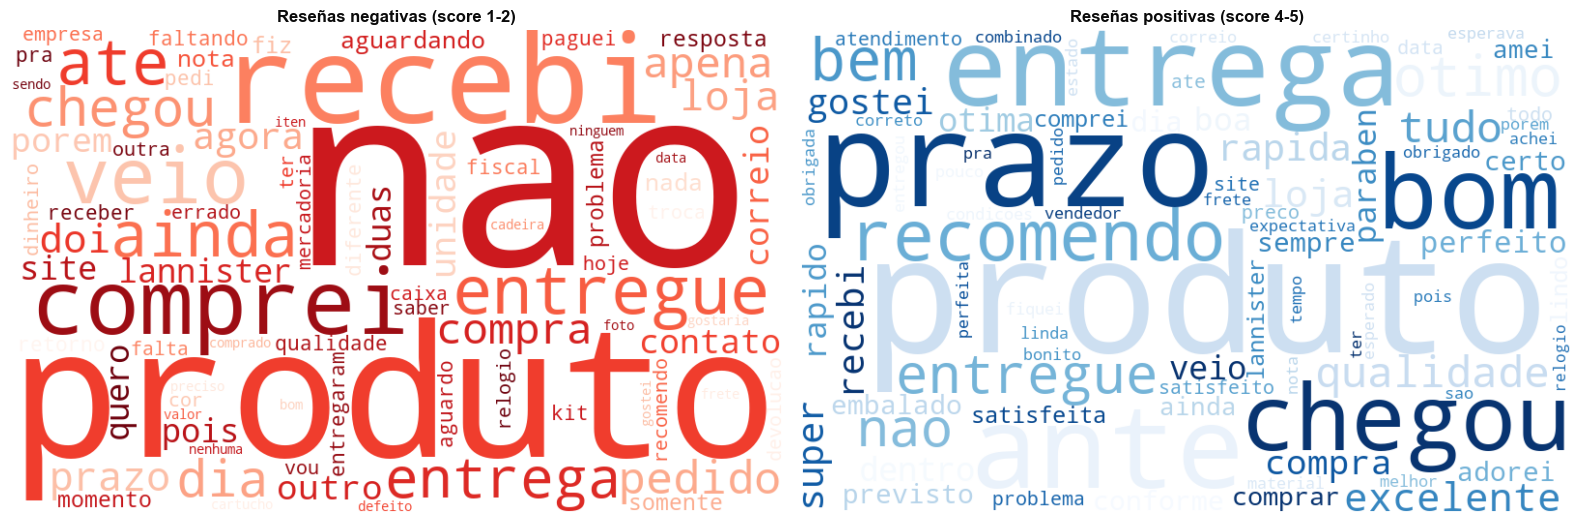

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

nube_neg = WordCloud(width=800, height=500, background_color="white",
                      colormap="Reds", max_words=80, collocations=False).generate(texto_neg)
axes[0].imshow(nube_neg, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Reseñas negativas (score 1-2)")

nube_pos = WordCloud(width=800, height=500, background_color="white",
                      colormap="Blues", max_words=80, collocations=False).generate(texto_pos)
axes[1].imshow(nube_pos, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Reseñas positivas (score 4-5)")

plt.tight_layout()
guardar_fig()
plt.show()

**Insight:** en las **negativas** predominan palabras de queja sobre **entrega/atraso/producto** ("prazo", "atraso", "chegou", "recebi"), mientras que en las **positivas** predominan elogios y menciones al **cumplimiento del plazo** — la misma conclusión que ya se veía con `envio_demorado`, ahora confirmada **desde el texto libre**.

## Ranking — 15 palabras más frecuentes en reseñas negativas

**Qué hacemos:** contamos frecuencia con `Counter` y mostramos las 15 palabras más usadas en las reseñas de 1-2 ★.

**Para qué:** complementar la nube con un **número concreto de frecuencia** por palabra, más fácil de citar en el informe que una imagen.

In [7]:
top_negativas = pd.DataFrame(
    Counter(texto_neg.split()).most_common(15), columns=["palabra", "frecuencia"]
)
top_negativas

,palabra,frecuencia
0,nao,9860
1,produto,6817
2,recebi,4658
3,comprei,2895
4,veio,2113
5,entregue,1824
6,ainda,1748
7,ate,1741
8,entrega,1643
9,chegou,1514


**Insight:** las palabras más frecuentes en las reseñas negativas están **directamente vinculadas al proceso de entrega**, reforzando que la logística —y no el producto en sí— es la **principal fuente de insatisfacción** expresada por escrito. Esa es la evidencia cualitativa de la hipótesis 2, lista para contrastarse con la evidencia cuantitativa del notebook siguiente.

**Siguiente paso:** `10_contraste_de_hipotesis.ipynb` — los tests estadísticos y las conclusiones del pipeline.